# 实验六 - 基础版：基于剪影的形状优化## 📋 实验目标从球体优化到牛模型，仅使用剪影Loss进行形状优化## ⚙️ 参数配置- **优化器**: SGD (lr=1.0, momentum=0.9)- **迭代次数**: 300 epochs- **正则化权重**: laplacian=1.0, edge=0.1, normal=0.01- **输出目录**: `output_meshes/`## 📊 预期结果- 形状基本贴合目标- 最终Silhouette Loss < 0.002- 可能存在后期震荡---

## 1. 环境检查

In [5]:
import torch
import pytorch3d
print(f"PyTorch版本: {torch.__version__}")
print(f"PyTorch3D版本: {pytorch3d.__version__}")
print(f"CUDA可用: {torch.cuda.is_available()}")

PyTorch版本: 2.9.1+cu128
PyTorch3D版本: 0.7.8
CUDA可用: True


## 2. 完整代码（基础版）

迭代步数: 299/300 | 总 Loss: 0.0179 | 剪影误差: 0.0141
[*] 已保存当前 3D 模型至: output_meshes/mesh_epoch_299.obj


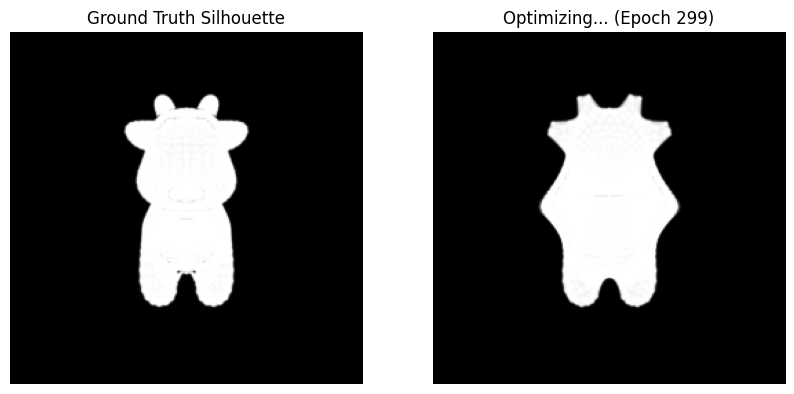

优化完成！所有中间状态的 .obj 文件已保存在 output_meshes 文件夹中。


In [6]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output 

import pytorch3d
# 引入 save_obj 用于保存 3D 模型
from pytorch3d.io import load_obj, save_obj
from pytorch3d.structures import Meshes
from pytorch3d.utils import ico_sphere
from pytorch3d.loss import mesh_edge_loss, mesh_laplacian_smoothing, mesh_normal_consistency
from pytorch3d.renderer import (
    look_at_view_transform, FoVPerspectiveCameras,
    RasterizationSettings, MeshRasterizer, SoftSilhouetteShader, BlendParams
)

# 确认设备
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"当前运行设备: {device}")
print(f"PyTorch3D 版本: {pytorch3d.__version__}")

# ---------------------------------------------------------
# 1. 直接读取助教打包好的本地模型文件
# ---------------------------------------------------------
obj_path = "/mnt/workspace/.configs/code-server/extensions/ms-toolsai.jupyter-renderers-1.3.0-universal/cow.obj" # 使用绝对路径
if not os.path.exists(obj_path):
    raise FileNotFoundError("未找到 cow.obj，请确保代码文件与 obj 文件在同一目录下！")

# 准备目标数据与归一化处理
verts, faces, _ = load_obj(obj_path)
faces_idx = faces.verts_idx.to(device)
verts = verts.to(device)
verts = (verts - verts.mean(0)) / max(verts.abs().max(0)[0]) 
cow_mesh = Meshes(verts=[verts], faces=[faces_idx])

# ---------------------------------------------------------
# 2. 渲染管线与摄像机配置
# ---------------------------------------------------------
num_views = 20
cameras = FoVPerspectiveCameras(device=device, 
                                R=look_at_view_transform(2.7, torch.zeros(num_views), torch.linspace(-180, 180, num_views))[0], 
                                T=look_at_view_transform(2.7, torch.zeros(num_views), torch.linspace(-180, 180, num_views))[1])

rasterizer = MeshRasterizer(cameras=cameras, 
                            raster_settings=RasterizationSettings(image_size=256, blur_radius=np.log(1./1e-4 - 1.)*1e-4, faces_per_pixel=50))
shader = SoftSilhouetteShader(blend_params=BlendParams(sigma=1e-4, gamma=1e-4))

target_silhouette = shader(rasterizer(cow_mesh.extend(num_views)), cow_mesh.extend(num_views))[..., 3]

# ---------------------------------------------------------
# 3. 优化器初始化：从圆球开始
# ---------------------------------------------------------
src_mesh = ico_sphere(4, device)
deform_verts = torch.zeros_like(src_mesh.verts_packed(), requires_grad=True)
optimizer = torch.optim.SGD([deform_verts], lr=1.0, momentum=0.9)

# 创建保存中间结果的文件夹
output_dir = "output_meshes"
os.makedirs(output_dir, exist_ok=True)
print(f"中间模型将保存在目录: ./{output_dir}/")

# ---------------------------------------------------------
# 4. 可微渲染优化循环
# ---------------------------------------------------------
epochs = 300
for i in range(epochs):
    optimizer.zero_grad()
    
    # 依据当前计算出的偏移量，形变生成新的 Mesh
    new_src_mesh = src_mesh.offset_verts(deform_verts)
    
    # 渲染当前 Mesh 的 20 个视角剪影
    pred_silhouette = shader(rasterizer(new_src_mesh.extend(num_views)), new_src_mesh.extend(num_views))[..., 3]
    
    # 【核心损失】：均方误差 + 三大正则化惩罚
    loss_silhouette = ((pred_silhouette - target_silhouette) ** 2).mean()
    loss = loss_silhouette + \
           1.0 * mesh_laplacian_smoothing(new_src_mesh) + \
           0.1 * mesh_edge_loss(new_src_mesh) + \
           0.01 * mesh_normal_consistency(new_src_mesh)
    
    loss.backward()
    optimizer.step()

    # 可视化与模型保存逻辑：每 20 步执行一次
    if i % 20 == 0 or i == epochs - 1:
        clear_output(wait=True)
        print(f"迭代步数: {i:03d}/{epochs} | 总 Loss: {loss.item():.4f} | 剪影误差: {loss_silhouette.item():.4f}")
        
        # 提取当前网格的顶点和面，并保存为 .obj 文件
        # verts_list()[0] 和 faces_list()[0] 用于获取 batch 中第一个（也是唯一一个）网格的数据
        current_verts = new_src_mesh.verts_list()[0]
        current_faces = new_src_mesh.faces_list()[0]
        
        save_path = os.path.join(output_dir, f"mesh_epoch_{i:03d}.obj")
        save_obj(save_path, current_verts, current_faces)
        print(f"[*] 已保存当前 3D 模型至: {save_path}")
        
        # 刷新对比图
        fig, ax = plt.subplots(1, 2, figsize=(10, 5))
        
        ax[0].imshow(target_silhouette[0].cpu().numpy(), cmap='gray')
        ax[0].set_title("Ground Truth Silhouette")
        ax[0].axis("off")
        
        ax[1].imshow(pred_silhouette[0].detach().cpu().numpy(), cmap='gray')
        ax[1].set_title(f"Optimizing... (Epoch {i})")
        ax[1].axis("off")
        
        plt.show()

print(f"优化完成！所有中间状态的 .obj 文件已保存在 {output_dir} 文件夹中。")

## 📝 结果分析### 观察到的现象- ✅ 形状能够从球体逐渐变形为牛的轮廓- ⚠️ 后期（250-300 epoch）Loss存在震荡- ⚠️ 学习率固定为1.0，后期步长过大### 改进方向1. 使用Adam优化器替代SGD2. 添加学习率衰减机制3. 增加训练轮次至500👉 **下一步**: 查看 `2_improved_adam.ipynb`